In [ ]:
# 1. Настройка путей 
import sys
from pathlib import Path

# Просто подняться на уровень вверх от notebooks/
project_root = Path().resolve().parent

# Добавляем корень проекта в sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added to sys.path: {project_root}")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from config import RAW_DATA_DIR
from src.db.queries import run_query

# Загрузка данных
df = pd.read_csv(RAW_DATA_DIR / "third_wave_coffee_shop.csv", parse_dates=['datetime', 'sale_date'])


In [3]:
from scipy.stats import norm
from cycler import cycler
import matplotlib.colors as mcolors

In [4]:
# 1. ФУНКЦИЯ ИНВЕРСИИ ЦВЕТОВ
def invert_color(color):
    """Инвертирует любой цвет, понятный matplotlib"""
    if color is None or str(color).lower() in ('none', 'inherit', 'auto'):
        return color
    try:
        rgb = mcolors.to_rgb(color)
        return mcolors.to_hex(tuple(1.0 - x for x in rgb))
    except (ValueError, TypeError):
        return color

def inverse_plot_colorscheme():
    """Применяет инвертированную цветовую схему к текущим настройкам"""
    # Фоны и текст
    for param in ['figure.facecolor', 'axes.facecolor', 'axes.labelcolor',
                  'text.color', 'xtick.color', 'ytick.color', 'axes.edgecolor']:
        plt.rcParams[param] = invert_color(plt.rcParams[param])
    
    # Сетка
    plt.rcParams['grid.color'] = invert_color(plt.rcParams['grid.color'])
    
    # Палитра графиков
    old_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    new_colors = [invert_color(c) for c in old_colors]
    plt.rcParams['axes.prop_cycle'] = cycler(color=new_colors)
    
    # Граница легенды
    lec = plt.rcParams['legend.edgecolor']
    try:
        plt.rcParams['legend.edgecolor'] = str(1.0 - float(lec))
    except (ValueError, TypeError):
        plt.rcParams['legend.edgecolor'] = invert_color(lec)

# 2. НАСТРОЙКА СТИЛЯ (Seaborn + инверсия)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
inverse_plot_colorscheme()  # применяем после sns.set_theme!

In [6]:
# Добавление месяца и часа (если нужно для группировки)
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['date'] = df['datetime'].dt.date


In [7]:
# Создание df_tx — только уникальные транзакции
df_tx = df.drop_duplicates(subset='transaction_id').reset_index(drop=True)

#### 4. Визуализация распределения цен (drink_price и total_cost)

In [8]:
# 1. Определяем желаемый порядок категорий
time_order = ['Morning', 'Afternoon', 'Evening', 'Outside hour']

# 2. Преобразуем в упорядоченную категорию
#   (если в данных есть заначения не из time_order - они станут NaN)
df_tx['time_of_day'] = pd.Categorical(
    df_tx['time_of_day'],
    categories=time_order,
    ordered=False
)

# 3. Агрегация с named aggregation (современный, прозрачный стиль)
time_sales = (
    df_tx
    .groupby('time_of_day', observed=False)
    .agg(
        num_transactions=('transaction_id', 'count'),   # явно: считаем ID
        total_revenue=('total_cost', 'sum'),
        avg_check=('total_cost', 'mean')
    )
    .round(2)
    .reset_index()  # для удобства визуализации
)

# Проверяем: все ли категории присутствуют (даже с NaN/0)
print("Агрегированные данные:")
print(time_sales)



Агрегированные данные:
    time_of_day  num_transactions  total_revenue  avg_check
0       Morning              1175       558610.0     475.41
1     Afternoon              1918       891450.0     464.78
2       Evening               453       217550.0     480.24
3  Outside hour                 0            0.0        NaN


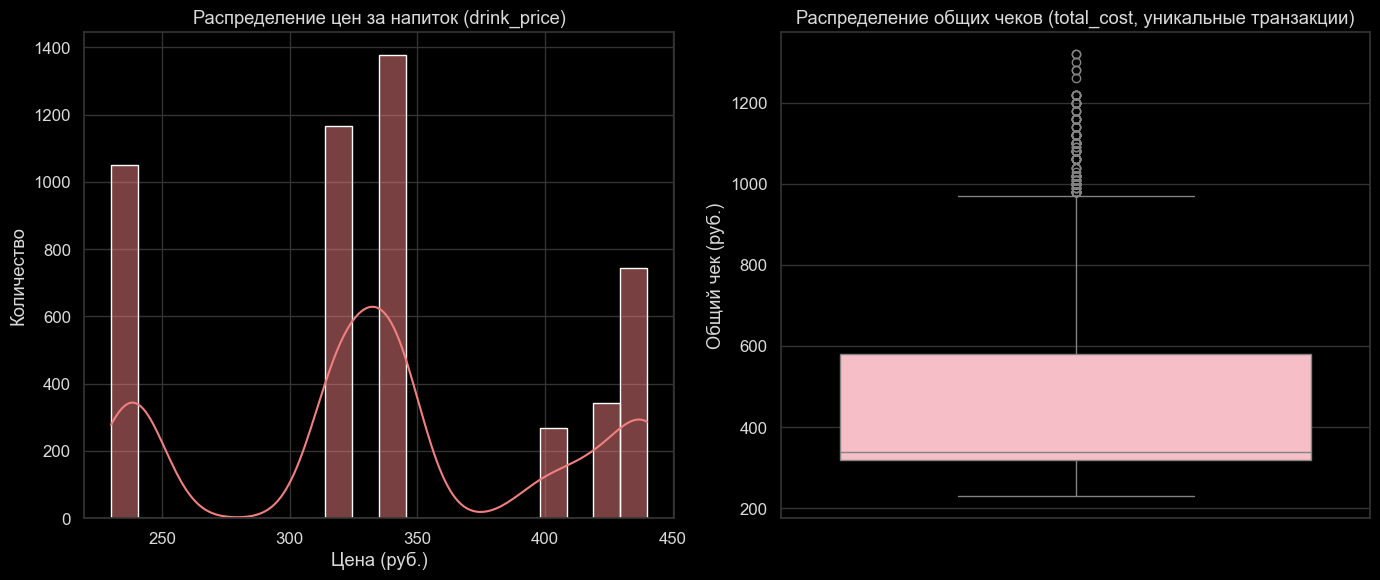

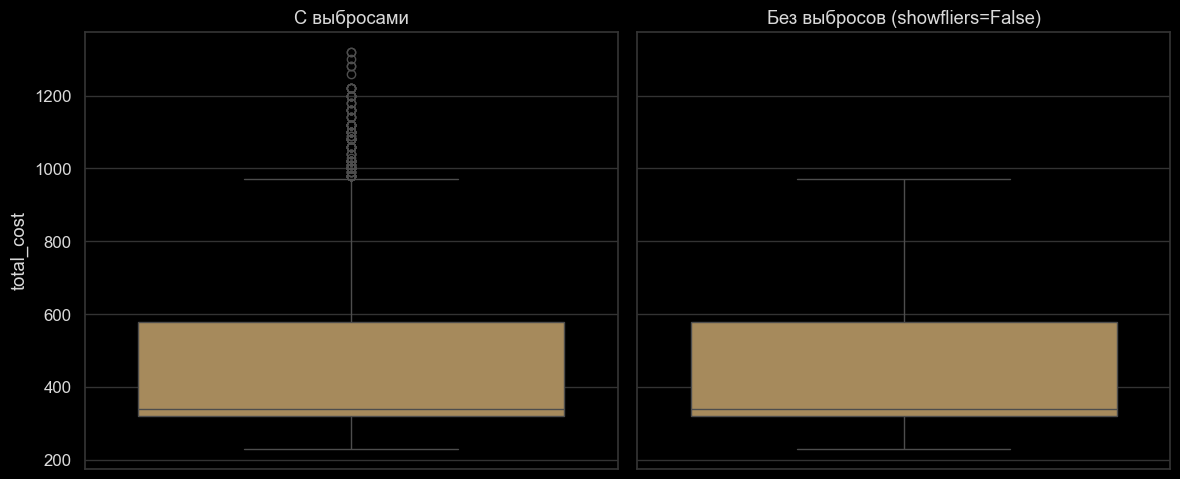

In [9]:
# Подготовка данных
drink_prices = df['drink_price']
unique_checks = df_tx['total_cost']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Гистограмма цен за напиток
sns.histplot(drink_prices, kde=True, ax=axes[0], color='lightcoral', bins=20)
axes[0].set_title('Распределение цен за напиток (drink_price)')
axes[0].set_xlabel('Цена (руб.)')
axes[0].set_ylabel('Количество')

# 2. Boxplot чеков (уникальные транзакции)
sns.boxplot(y=unique_checks, ax=axes[1], color='lightpink')
axes[1].set_title('Распределение общих чеков (total_cost, уникальные транзакции)')
axes[1].set_ylabel('Общий чек (руб.)')

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.boxplot(y=unique_checks, ax=ax1)
ax1.set_title('С выбросами')

sns.boxplot(y=unique_checks, ax=ax2, showfliers=False)
ax2.set_title('Без выбросов (showfliers=False)')

plt.tight_layout()
plt.show()

#### 5.  Продажи по времени дня (time_of_day)

,time_of_day,num_transactions,total_revenue,avg_check
0,Morning,1175,558610.0,475.41
1,Afternoon,1918,891450.0,464.78
2,Evening,453,217550.0,480.24


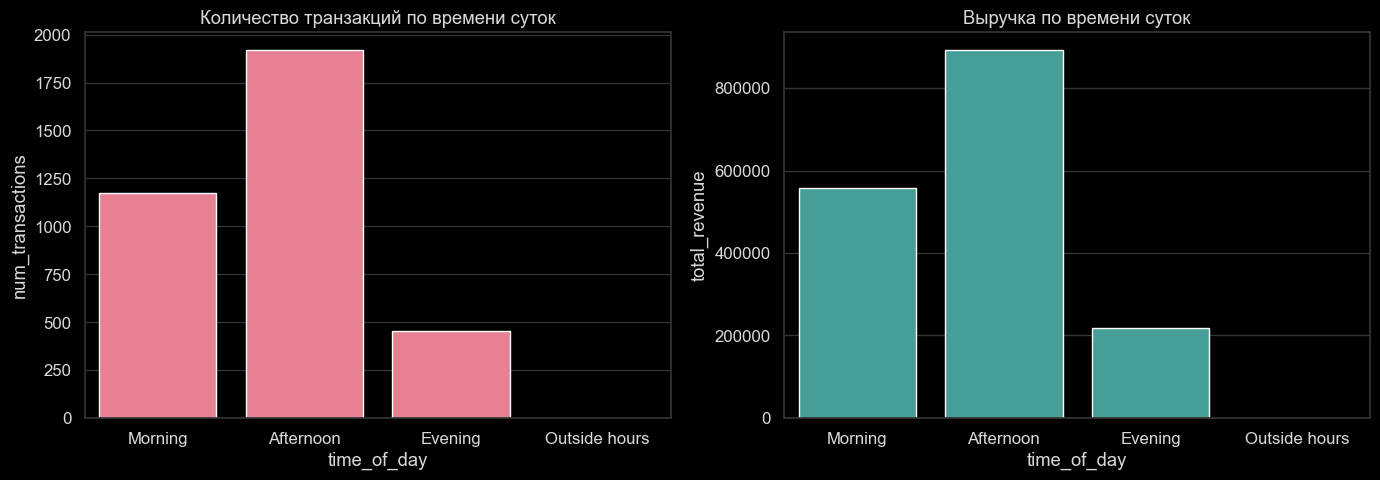

In [10]:
time_order = ['Morning', 'Afternoon', 'Evening', 'Outside hours']

# Преобразуем в упорядоченную категорию 
df_tx['time_of_day'] = pd.Categorical(
    df_tx['time_of_day'],
    categories=time_order,
    ordered=True
)

time_sales = (
    df_tx
    .groupby('time_of_day', observed=True)
    .agg(
        num_transactions=('transaction_id', 'count'),   
        total_revenue=('total_cost', 'sum'),
        avg_check=('total_cost', 'mean')
    )
    .round(2)
    .reset_index()  
)

display(time_sales)

husl_colors = sns.color_palette("husl", n_colors=4) 
color_count = husl_colors[0]  
color_revenue = husl_colors[2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

sns.barplot(
    data=time_sales,
    x='time_of_day',
    y='num_transactions',
    order=time_order,
    ax=ax1,
    color=color_count  
)
ax1.set_title('Количество транзакций по времени суток')

sns.barplot(
    data=time_sales,
    x='time_of_day',
    y='total_revenue',
    order=time_order,
    ax=ax2,
    color=color_revenue  
)
ax2.set_title('Выручка по времени суток')

plt.tight_layout()
plt.show()

#### 6. Топ-кофе по популярности и выручке

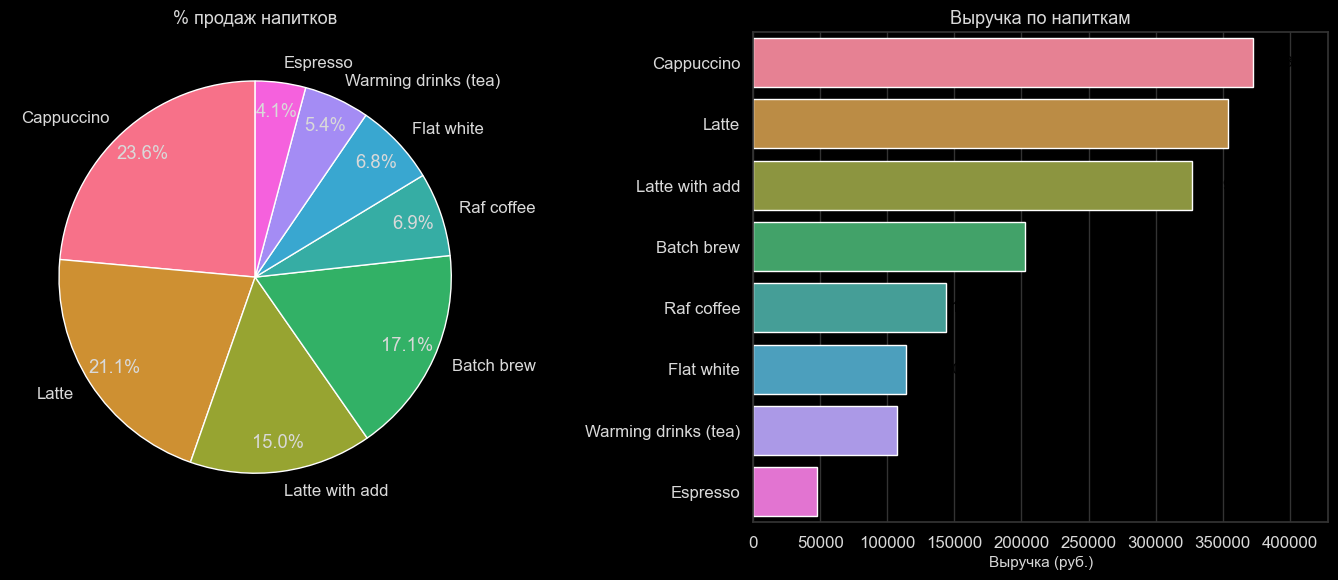

In [11]:
# Подготовка данных 
coffee_stats = df.groupby('coffee_name').agg(
    drinks_sold=('coffee_name', 'count'),
    revenue=('drink_price', 'sum')
).round(2).reset_index()

coffee_stats = coffee_stats.sort_values('revenue', ascending=False).head(8)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = sns.color_palette("husl", n_colors=len(coffee_stats))
ax1.pie(
    coffee_stats['drinks_sold'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85
)
ax1.set_title('% продаж напитков', fontsize=13)

# Bar chart
sns.barplot(
    data=coffee_stats,
    x='revenue',
    y='coffee_name',
    hue='coffee_name',       
    palette="husl",
    dodge=False,
    legend=False,            
    ax=ax2
)
ax2.set_xlabel('Выручка (руб.)', fontsize=11)
ax2.set_ylabel('')
ax2.set_title('Выручка по напиткам', fontsize=13)

max_revenue = coffee_stats['revenue'].max() 
ax2.set_xlim(0, max_revenue * 1.15)

for i, v in enumerate(coffee_stats['revenue']):
    ax2.text(v + max_revenue * 0.01, i, f'{int(v):,}',
             va='center', ha='left', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [12]:
coffee_revenue = (
    df
    .groupby('coffee_name', as_index=False)
    .agg(revenue=('drink_price', 'sum'),          
        quantity=('coffee_name', 'count'))       
    .sort_values('revenue', ascending=False)
    .head(8)
)

# Топ по выручке
fig = px.bar(
    coffee_revenue,
    x='coffee_name',
    y='revenue',
    title='Рейтинг напитков по выручке',
    labels={'coffee_name': 'Напиток', 'revenue': 'Выручка (₽)'},
    color='revenue',
    color_continuous_scale='Tealgrn'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

#### 7. Анализ по дням недели (is_weekend и day_name)

Выручка по дням недели:
           total_orders   revenue  avg_ticket
day_name                                     
Tuesday             538  253610.0      471.39
Saturday            517  253350.0      490.04
Thursday            524  247560.0      472.44
Wednesday           486  233870.0      481.21
Friday              496  230880.0      465.48
Monday              492  229420.0      466.30
Sunday              494  219360.0      444.05


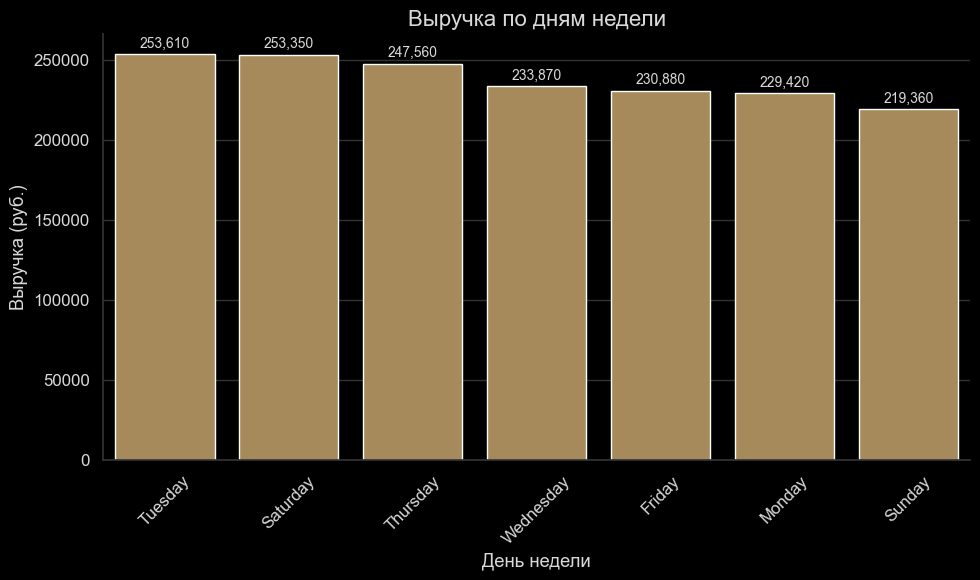


 Weekend vs Weekday:
            total_orders    revenue  avg_ticket
is_weekend                                     
Weekday             2536  1195340.0      471.35
Weekend             1011   472710.0      467.57


In [13]:
# Динамика по дням недели
day_stats = (
    df_tx
    .groupby('day_name', observed=False)
    .agg(
        total_orders=('transaction_id', 'count'),
        revenue=('total_cost', 'sum'),
        avg_ticket=('total_cost', 'mean'),
    )
    .round(2)
    .sort_values('revenue', ascending=False)
)

print("Выручка по дням недели:")
print(day_stats)
# Визуализация 
fig, ax = plt.subplots(figsize=(10, 6))

bars = sns.barplot(
    data=day_stats.reset_index(),
    x='day_name',
    y='revenue',
    ax=ax,
    errorbar=None
)

# Подписи значений
for i, (_, row) in enumerate(day_stats.iterrows()):
    ax.text(i, row['revenue'] + row['revenue'] * 0.01,
            f'{int(row["revenue"]):,}', 
            ha='center', va='bottom', fontsize=10)

ax.set_title('Выручка по дням недели', fontsize=16)
ax.set_xlabel('День недели')
ax.set_ylabel('Выручка (руб.)')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

# Weekend vs Weekday
weekend_stats = (
    df_tx
    .groupby('is_weekend', observed=False)
    .agg(
        total_orders=('transaction_id', 'count'),
        revenue=('total_cost', 'sum'),
        avg_ticket=('total_cost', 'mean')
    )
    .round(2)
)

# Индекс для наглядности
weekend_stats.index = weekend_stats.index.map({True: 'Weekend', False: 'Weekday'})

print("\n Weekend vs Weekday:")
print(weekend_stats)


#### Heatmap 

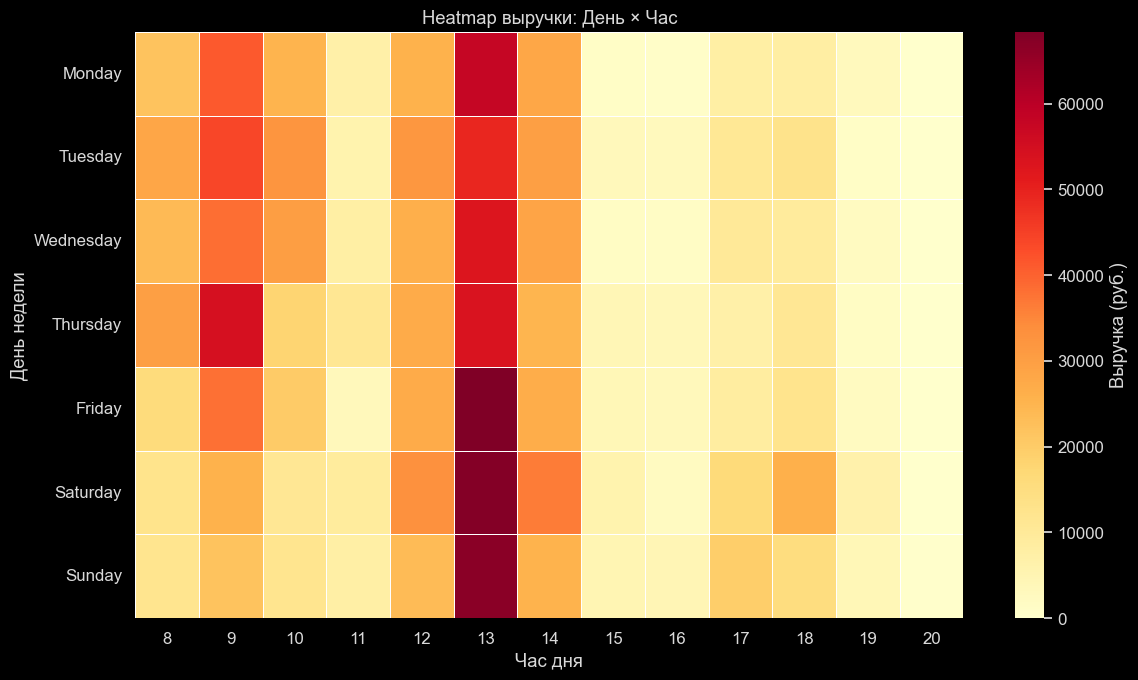

In [14]:
# Подготовка pivot
heatmap_data = df_tx.groupby(['day_name', 'hour'])['total_cost'].sum().unstack(fill_value=0)

# Порядок дней
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Выручка (руб.)'}, linewidths=0.5)
plt.title('Heatmap выручки: День × Час')
plt.xlabel('Час дня')
plt.ylabel('День недели')
plt.tight_layout()
plt.show()

#### 8. Распределение заказов по количеству напитков

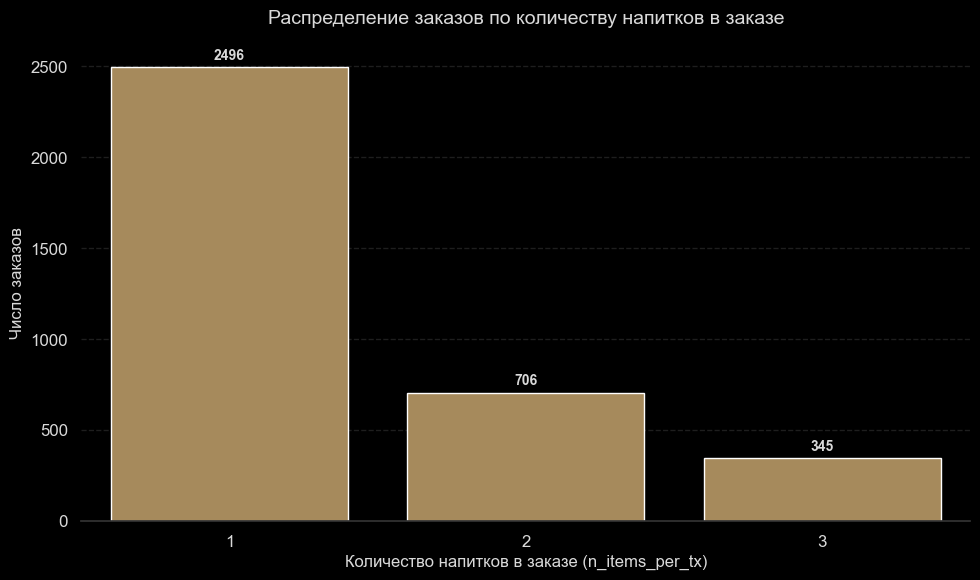


Распределение заказов по количеству напитков:
 n_items  orders_count  percent  cumulative_percent
       1          2496    70.37               70.37
       2           706    19.90               90.27
       3           345     9.73              100.00


In [15]:
# Добавляем n_items_per_tx
if 'n_items_per_tx' not in df.columns:
    df['n_items_per_tx'] = df.groupby('transaction_id').transform('size')

n_items_per_order = df.drop_duplicates('transaction_id')['n_items_per_tx']

dist = n_items_per_order.value_counts().sort_index()

# Таблица
orders_dist = dist.reset_index()
orders_dist.columns = ['n_items', 'orders_count']

# Проценты и накопленный %
total_orders = orders_dist['orders_count'].sum()
orders_dist['percent'] = (orders_dist['orders_count'] / total_orders * 100).round(2)
orders_dist['cumulative_percent'] = orders_dist['percent'].cumsum().round(2)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

bars = sns.barplot(
    data=orders_dist,
    x='n_items',
    y='orders_count',
    ax=ax,
    errorbar=None
)

# Подписи на столбцах
for p in bars.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2., 
        height + max(orders_dist['orders_count']) * 0.01,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Распределение заказов по количеству напитков в заказе', fontsize=14, pad=15)
ax.set_xlabel('Количество напитков в заказе (n_items_per_tx)', fontsize=12)
ax.set_ylabel('Число заказов', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(left=True, ax=ax)
plt.tight_layout()
plt.show()

# 4. Вывод таблицы 
print("\nРаспределение заказов по количеству напитков:")
print(orders_dist.to_string(index=False))

#### 9. Методы оплаты

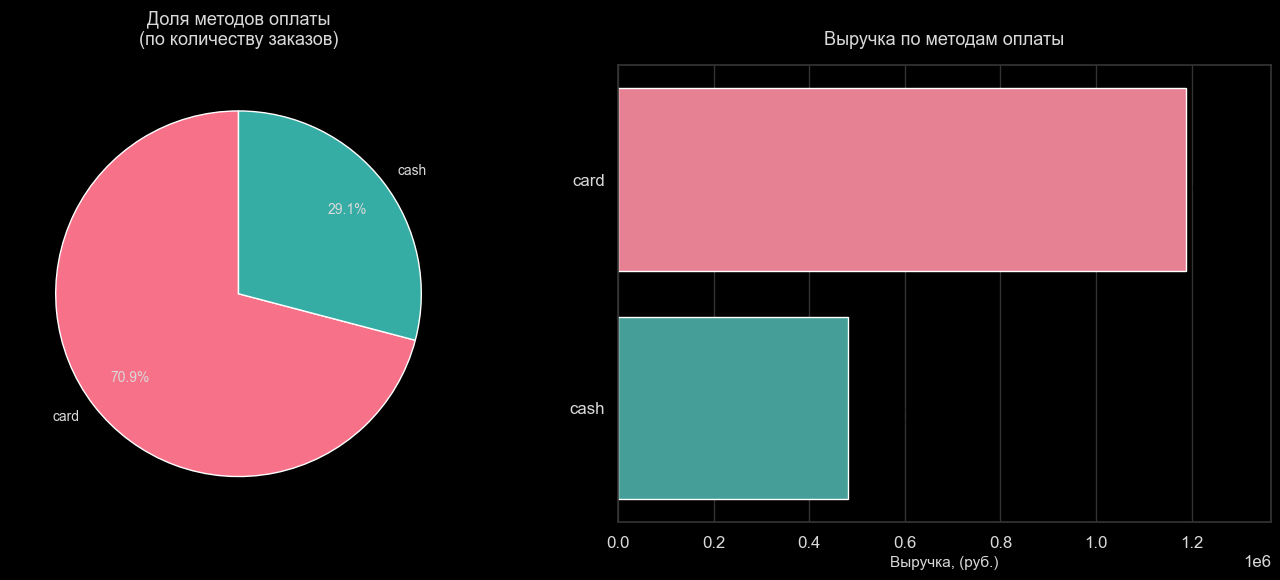


Статистика по оплате
payment_method  total_orders  total_revenue  percent_of_total
          card          2515      1187240.0             71.18
          cash          1032       480810.0             28.82


In [16]:
# Агрегация по способу оплаты
payment_stats = df_tx.groupby('payment_method', as_index=False).agg(
    total_orders=('transaction_id', 'count'),
    total_revenue=('total_cost', 'sum')
).round(2)

# Доля в общей выручке
total_revenue_all = payment_stats['total_revenue'].sum()
payment_stats['percent_of_total'] = (100 * payment_stats['total_revenue'] / total_revenue_all).round(2)

# Сортировка: по количеству заказов (для pie) — или по выручке (для bar)
payment_stats = payment_stats.sort_values('total_orders', ascending=False).reset_index(drop=True)

# 3. Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart: доля по количеству транзакций
colors = sns.color_palette("husl", n_colors=len(payment_stats))
ax1.pie(
    payment_stats['total_orders'],
    labels=payment_stats['payment_method'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)
ax1.set_title('Доля методов оплаты\n(по количеству заказов)', fontsize=13, pad=15)

# Bar chart: выручка
sns.barplot(
    data=payment_stats,
    x='total_revenue',
    y='payment_method',
    hue='payment_method',
    palette="husl",
    dodge=False,
    legend=False,
    ax=ax2
)
ax2.set_title('Выручка по методам оплаты', fontsize=13, pad=15)
ax2.set_xlabel('Выручка, (руб.)', fontsize=11)
ax2.set_ylabel('')

max_revenue = payment_stats['total_revenue'].max()
ax2.set_xlim(0, max_revenue * 1.15)  # ось на 15% справа

# Добавим значения на бары 
for i, row in payment_stats.iterrows():
    ax2.text(
        row['total_revenue'] + max_revenue * 0.01,  # Используем предвычисленное значение
        i,
        f"{int(row['total_revenue']):,}\n({row['percent_of_total']}%)",
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

# 4. Таблица для отчёта
print("\nСтатистика по оплате")
print(payment_stats[['payment_method', 'total_orders', 'total_revenue', 'percent_of_total', ]].to_string(index=False))

#### 10. Анализ клиентов (топ-клиенты по тратам)

             total_spent  num_transactions  avg_check
customer_id                                          
CUST_7393         2980.0                 4     745.00
CUST_9122         2640.0                 4     660.00
CUST_1235         2600.0                 3     866.67
CUST_6224         2420.0                 3     806.67
CUST_1726         2400.0                 3     800.00
CUST_7773         2220.0                 3     740.00
CUST_8554         2220.0                 2    1110.00
CUST_6489         2200.0                 3     733.33
CUST_8852         2140.0                 3     713.33
CUST_4168         2140.0                 4     535.00


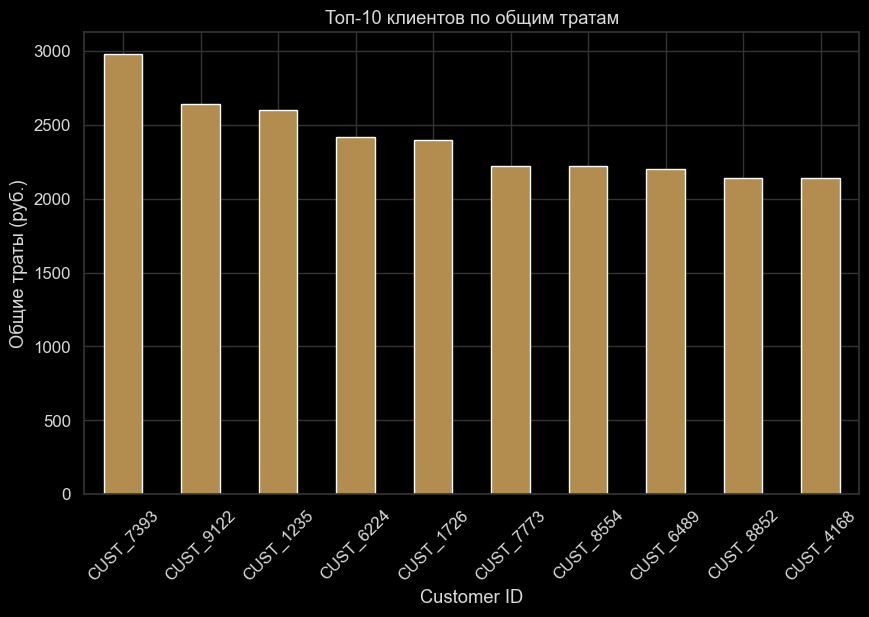

In [17]:
# Топ-10 клиентов по общим тратам
df_tx = df.groupby('transaction_id').first()[['customer_id', 'total_cost']].reset_index()

# Агрегируем по клиентам
customer_spend = (
    df_tx
    .groupby('customer_id', as_index=True)
    .agg(
        total_spent=('total_cost', 'sum'),
        num_transactions=('total_cost', 'size'),  
        avg_check=('total_cost', 'mean')
    )
    .round(2)
    .sort_values('total_spent', ascending=False)
    .head(10)
)

print(customer_spend)

# Визуализация
customer_spend['total_spent'].plot(kind='bar', figsize=(10, 6))
plt.title('Топ-10 клиентов по общим тратам')
plt.xlabel('Customer ID')
plt.ylabel('Общие траты (руб.)')
plt.xticks(rotation=45)
plt.show()

#### Временной анализ (нагрузка и планирование персонала)

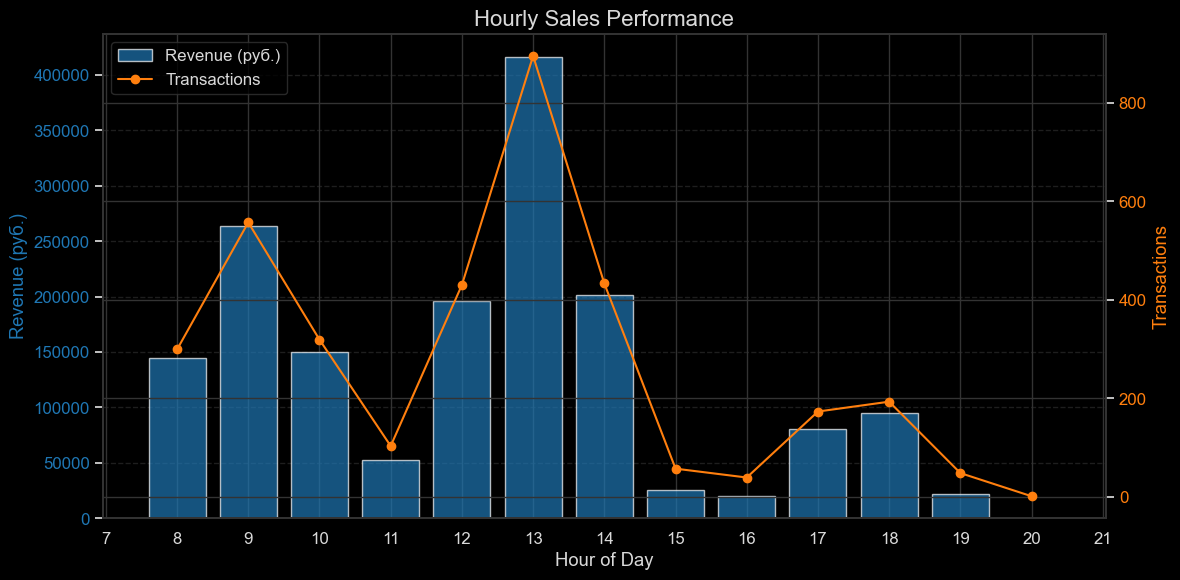

,hour,revenue,transactions,items_sold
0,8,145040.0,299,427
1,9,263820.0,557,792
2,10,149750.0,319,449
3,11,52650.0,103,159
4,12,195630.0,430,572
5,13,416210.0,895,1235
6,14,201050.0,433,593
7,15,25910.0,57,76
8,16,19800.0,39,57
9,17,80740.0,173,242


In [18]:
# 1. Агрегация по часам
hourly_sales = (
    df.groupby("hour", as_index=False)
      .agg(
          revenue=("drink_price", "sum"),
          transactions=("transaction_id", "nunique"),
          items_sold=("coffee_name", "count")  # количество напитков
      )
      .sort_values("hour")  # сортируем от 0 до 23
)

# 2. Визуализация
fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы: выручка
color = "tab:blue"
ax1.bar(hourly_sales["hour"], hourly_sales["revenue"], color=color, alpha=0.7, label="Revenue (руб.)")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Revenue (руб.)", color=color)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xticks(range(0, 24))
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# Добавим вторую ось для количества чеков (необязательно, но полезно)
ax2 = ax1.twinx()
color = "tab:orange"
ax2.plot(hourly_sales["hour"], hourly_sales["transactions"], 
         color=color, marker="o", linestyle="-", label="Transactions")
ax2.set_ylabel("Transactions", color=color)
ax2.tick_params(axis="y", labelcolor=color)

# Заголовок и легенда
plt.title("Hourly Sales Performance", fontsize=16)
fig.tight_layout()

# Объединённая легенда
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.show()

# Выведем таблицу для точности
hourly_sales

#### **Продажи напитков по неделям** с детализацией **по каждому напитку**

*   количество проданных единиц (`units_sold`);
*   общее количество напитков за неделю (`total_units_week`)
*   процент вклада каждого напитка в общую структуру продаж (`precentage`).

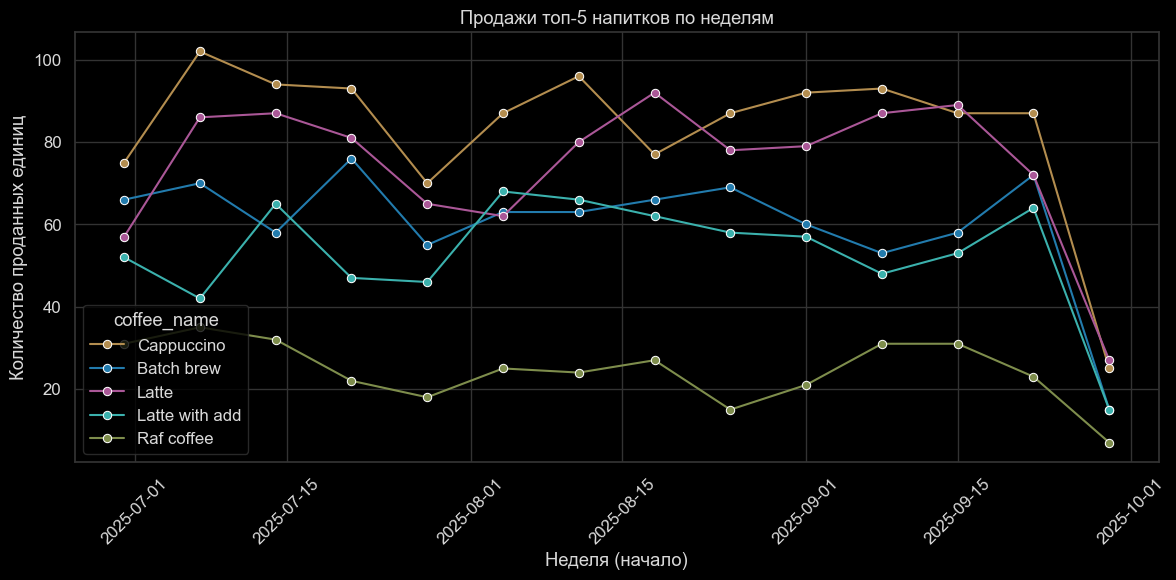

,week_start,coffee_name,units_sold,total_units_week,percentage
0,2025-06-30,Cappuccino,75,341,21.99
1,2025-06-30,Batch brew,66,341,19.35
2,2025-06-30,Latte,57,341,16.72
3,2025-06-30,Latte with add,52,341,15.25
4,2025-06-30,Raf coffee,31,341,9.09
5,2025-06-30,Flat white,25,341,7.33
6,2025-06-30,Warming drinks (tea),20,341,5.87
7,2025-06-30,Espresso,15,341,4.40
8,2025-07-07,Cappuccino,102,400,25.50
9,2025-07-07,Latte,86,400,21.50


In [19]:
# 1 Определяем начало недели (понедельник) для  каждой строки
df['week_start'] = df['sale_date'].dt.to_period('W').dt.start_time

# 2. Группируем по неделе и названию напитка → считаем количество продаж
weekly_drink_sales = (
    df
    .groupby(['week_start', 'coffee_name'])
    .size()
    .reset_index(name='units_sold')
)    

# 3. Считаем общее число напитков за каждую неделю
weekly_totals = (
    weekly_drink_sales
    .groupby('week_start')['units_sold']
    .sum()
    .reset_index(name='total_units_week')
)

# 4. Объединяем и считаем процент
result = weekly_drink_sales.merge(weekly_totals, on='week_start')
result['percentage'] = (result['units_sold'] / result['total_units_week'] * 100).round(2)

# 5. Сортируем: по неделе, затем по объёму продаж (убывание)
result = result.sort_values(['week_start', 'units_sold'], ascending=[True, False]).reset_index(drop=True)

# Топ-5 напитков за все время (для фильтрации шума)
top_drinks = df['coffee_name'].value_counts().head(5).index
result_top = result[result['coffee_name'].isin(top_drinks)]


# Построение графика
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=result_top,
    x='week_start',
    y='units_sold',
    hue='coffee_name',
    marker='o'
)
plt.title('Продажи топ-5 напитков по неделям')
plt.xlabel('Неделя (начало)')
plt.ylabel('Количество проданных единиц')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Показываем результат
display(result.head(16))


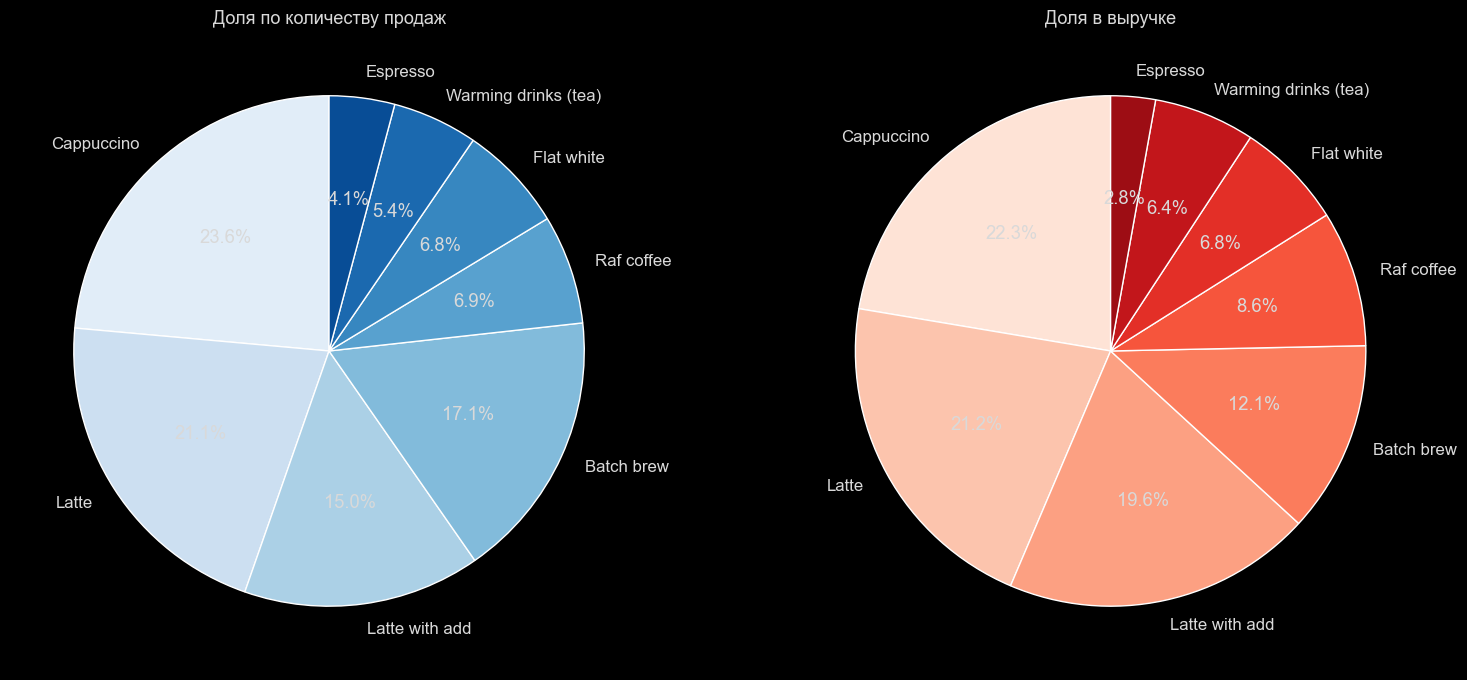

In [ ]:
# Подготовка данных
coffee_stats = df.groupby('coffee_name').agg(
    drinks_sold=('coffee_name', 'count'),
    revenue=('drink_price', 'sum')
).round(2).reset_index()

coffee_stats = coffee_stats.sort_values('revenue', ascending=False).head(8)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Доля по количеству
axes[0].pie(
    coffee_stats['drinks_sold'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Blues", len(coffee_stats)),
    startangle=90
)
axes[0].set_title('Доля по количеству продаж', fontsize=13)

# 2. Доля по выручке
axes[1].pie(
    coffee_stats['revenue'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Reds", len(coffee_stats)),
    startangle=90
)
axes[1].set_title('Доля в выручке', fontsize=13)

plt.tight_layout()
plt.show()

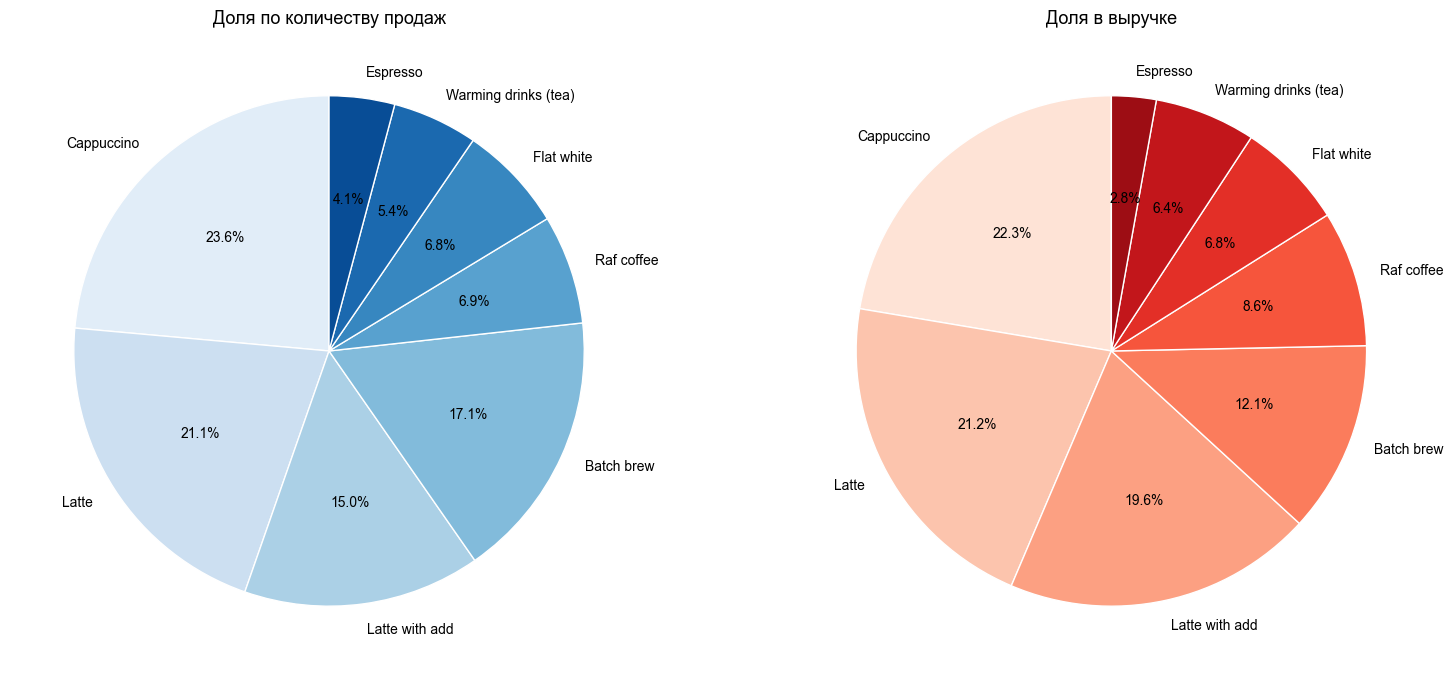

In [21]:
# Подготовка данных
coffee_stats = df.groupby('coffee_name').agg(
    drinks_sold=('coffee_name', 'count'),
    revenue=('drink_price', 'sum')
).round(2).reset_index()

coffee_stats = coffee_stats.sort_values('revenue', ascending=False).head(8)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Доля по количеству продаж
axes[0].pie(
    coffee_stats['drinks_sold'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Blues", len(coffee_stats)),
    startangle=90,
    textprops={'color': 'black', 'fontsize': 10}  # <-- Делаем текст черным
)
axes[0].set_title('Доля по количеству продаж', fontsize=13, color='black')

# 2. Доля по выручке
axes[1].pie(
    coffee_stats['revenue'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Reds", len(coffee_stats)),
    startangle=90,
    textprops={'color': 'black', 'fontsize': 10}  # <-- Делаем текст черным
)
axes[1].set_title('Доля в выручке', fontsize=13, color='black')

# Устанавливаем светлый фон для всего графика
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()